In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    SELECT *
    FROM checker 
    WHERE uid LIKE "user_%"
"""
df = pd.read_sql(query, connect, parse_dates=['first_commit_ts', 'first_view_ts'])

In [4]:
query = """
    SELECT 
        p.uid,
        AVG((unixepoch(t.first_commit_ts) - d.deadlines) /3600) AS avg_diff,
        COUNT(DISTINCT p.datetime) AS pageviews,
        COUNT(DISTINCT c.timestamp) AS num_commits
    
    FROM test t
    JOIN pageviews p ON t.uid = p.uid
    JOIN deadlines d ON t.labname = d.labs
    JOIN (SELECT * FROM checker WHERE labname != 'project1') AS c ON t.uid = c.uid
    WHERE t.labname != 'project1'
    GROUP BY t.uid

"""
df = pd.read_sql(query, connect, parse_dates=['first_commit_ts', 'first_view_ts'])
df.shape

(11, 4)

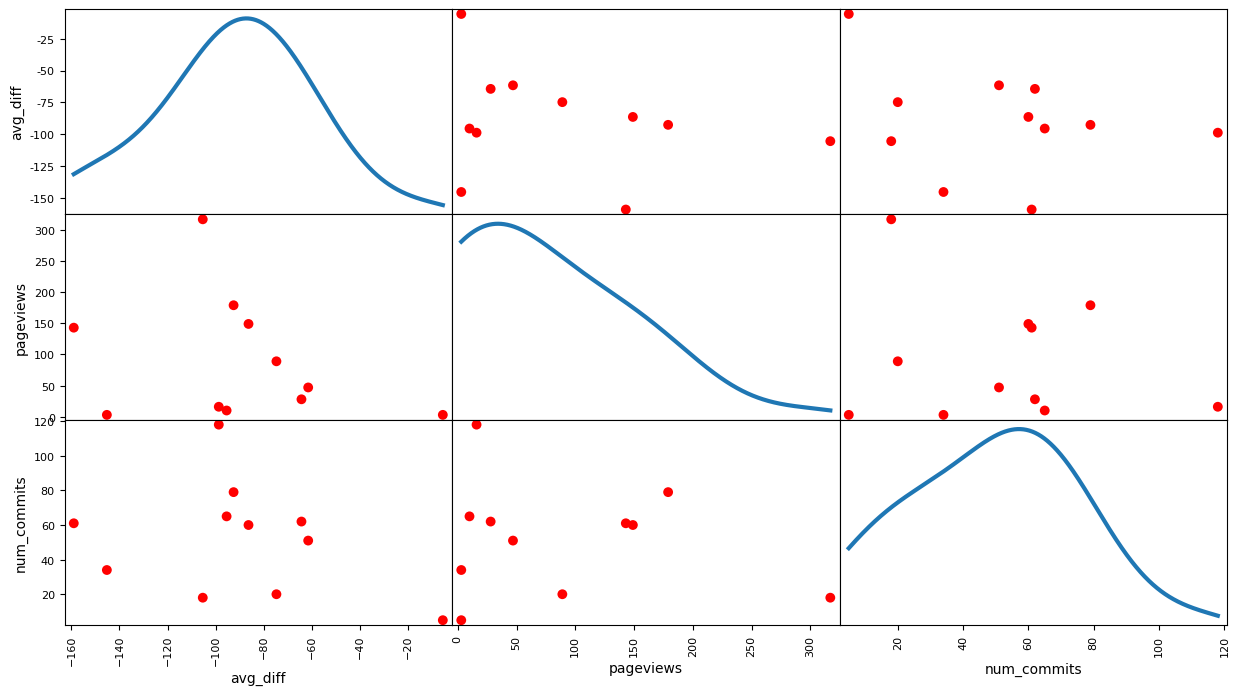

In [5]:
scatter_matrix(df, diagonal='kde', figsize=(15,8), s=200, c='red', alpha=1, density_kwds={'lw':3});

In [6]:
connect.close()

### Можно ли сказать, что если у пользователя мало просмотров страниц, то, вероятно, у него мало и коммитов?
### Можно ли сказать, что если у пользователя мало просмотров страниц, то, скорее всего, средняя разница между первым коммитом и крайним сроком выполнения лабораторной работы невелика?
### Можно ли сказать, что есть много пользователей с малым количеством коммитов и несколько с большим количеством коммитов
### Можно ли сказать, что есть много пользователей с небольшой средней разницей и несколько пользователей с большой средней разницей

## Нет
## Нет
## Да
## Нет